# Pseudospectral Methods, Part VI: Optimal Control with SNOPT

So far we've used pseudospectral methods to solve **forward** problems and (in Part IV) to compute
**sensitivities** of cost functionals to parameters via the discrete adjoint. This notebook turns
all that machinery sideways. Given a dynamical system $\dot q = f(q, u, t)$ with **freely choosable
control** $u(t)$, find the control history that minimizes some cost functional subject to
boundary conditions.

This is *direct collocation* via pseudospectral transcription, the workhorse of trajectory
optimization at NASA, SpaceX, Boeing, and most academic OC research. The pseudospectral grid is
the discretization, the differentiation matrix is the dynamics-defect Jacobian, and the resulting
sparse nonlinear program is fed to a sequential-quadratic-programming solver — **SNOPT** in
production, **IPOPT** as the open-source alternative, **SLSQP** for our toy demo here. The
**costates** that fall out are exactly the discrete adjoints from Part IV, applied to the
defect constraints.

Outline:

1. The optimal control problem and direct vs indirect methods.
2. Legendre–Gauss–Lobatto (LGL) pseudospectral transcription.
3. The NLP that comes out, and what makes it sparse.
4. SNOPT, IPOPT, SLSQP: when to reach for which.
5. Worked example: the **brachistochrone** — minimum-time descent of a bead under gravity along
   a frictionless wire — solved end to end and validated against the analytic cycloid.
6. Costate estimation: the Lagrange multipliers of the NLP *are* the Pontryagin costates,
   recovered automatically (and equal to the discrete adjoints of the dynamics).
7. Connection to real-time adaptive control problems.

In [1]:
import numpy as np
import scipy.optimize as opt
import scipy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    '''Trefethen SMM Program 1: CGL points and 1D differentiation matrix on [-1, 1].
    Returns x with x[0] = 1, x[N] = -1.'''
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_ascending(N):
    '''Same as cheb(N) but with x in ASCENDING order (x[0] = -1, x[N] = 1) -
    the natural orientation when we use this for time discretization.'''
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]

## 1. The optimal control problem

A typical (Bolza-form) OCP looks like

$$
\min_{q(\cdot),\,u(\cdot),\,T} \;\; J = \Phi\bigl(q(0), q(T), T\bigr) + \int_0^T \mathcal{L}\bigl(q(t), u(t), t\bigr)\,dt,
$$

subject to
$$
\dot q(t) = f\bigl(q(t), u(t), t\bigr),\qquad t \in [0, T],
$$
plus boundary conditions $g_0(q(0)) = 0$, $g_T(q(T)) = 0$ and (often) path constraints
$h(q,u,t) \le 0$.

Here $q \in \mathbb{R}^{n_q}$ is the state, $u \in \mathbb{R}^{n_u}$ is the control, $T$ may be
fixed or free, $\Phi$ is the *Mayer* (terminal) cost, and $\mathcal L$ is the *Lagrangian*
(running) cost. Examples:

* **Minimum-time** problems: $\mathcal{L} = 0$, $\Phi = T$.  *Brachistochrone*, missile-intercept,
  fastest-loop-closure for a controller.
* **Minimum-energy / -fuel** problems: $\mathcal{L} = \|u\|^2$ or $\sum_i |u_i|$. LQR and rocket
  ascent both fit here.
* **Tracking / regulation** problems: $\mathcal{L} = \|q - q_\mathrm{ref}\|_Q^2 + \|u\|_R^2$.
  Standard model-predictive control with terminal-cost $\Phi$.

### Direct vs indirect methods

There are two routes from the OCP to a numerical solution:

* **Indirect.** Apply Pontryagin's Maximum Principle: introduce the costate $\lambda(t)$, write
  the Hamiltonian $H = \mathcal L + \lambda^\top f$, derive necessary conditions
  $\dot q = \partial H/\partial \lambda$, $\dot\lambda = -\partial H/\partial q$, and the
  optimality condition $\partial H/\partial u = 0$ (or its bang-bang variant). Solve the resulting
  two-point BVP for the augmented system $(q, \lambda)$.
* **Direct.** Discretize $q(\cdot)$, $u(\cdot)$ on a grid, *then* optimize over the discrete
  variables subject to defect constraints (the discretized dynamics). The result is a finite-dim
  NLP, solved by SQP or interior-point methods.

Indirect methods give the most physical insight (you literally see the costates) but require
extra machinery — guessing $\lambda(0)$ to shoot, dealing with discontinuities at switching
surfaces, etc. Direct methods are more robust, easier to code, and *also* recover the costates
(see §6 below). For all but the simplest problems, **direct is the standard production approach**.

### Pseudospectral as the discretization of choice

For the direct-method discretization we have several options:

| Method | Convergence | Sparsity | Production use |
|---|---|---|---|
| Single shooting | depends | very dense | rarely |
| Multiple shooting | typically 4th order | block-banded | acados, ACADO |
| FD collocation (e.g. Hermite-Simpson) | 4th order | banded | DIRCOL, GPOPS-II legacy |
| **Pseudospectral collocation** | **spectral (exponential)** | **dense per segment, banded across segments** | **GPOPS-II, DIDO, PSOPT** |

The pseudospectral payoff is the same as in Parts I–IV: for a **smooth** trajectory,
spectral convergence means a 50-node solution is competitive with several thousand nodes of
finite differences. The price is denser block-Jacobian structure within each segment — but a good
SQP solver handles that fine.

## 2. LGL pseudospectral transcription

We approximate $q$ and $u$ by polynomials of degree $N$ on $[0, T]$, collocated at the $N+1$
**Legendre–Gauss–Lobatto** nodes (the same CGL nodes we've been using throughout — they're the
extrema of $T_N$, equivalently the zeros of $(1-x^2)P_N'(x)$, *modulo* a different orthogonality
weighting that doesn't affect the differentiation matrix).

Map physical time $t \in [0, T]$ to the standard interval $\tau \in [-1, 1]$ via
$t = \tfrac{T}{2}(\tau + 1)$, so $\frac{dq}{dt} = \frac{2}{T}\,\frac{dq}{d\tau}$.

Approximating $q(t) \approx Q_i := q(t_i)$ at each node, the **defect constraint** at node $i$ is

$$
\boxed{\;\frac{2}{T}\,\bigl(D\,Q\bigr)_i \;=\; f\bigl(Q_i, U_i, t_i\bigr),\qquad i = 0, 1, \dots, N.\;}
$$

This says: the polynomial whose values at the LGL nodes are $Q_i$ has, at each node, a slope that
matches the dynamics. If the true solution is smooth, the polynomial is its spectral interpolant
and the defects close up at spectral rate.

### Costs

Mayer terms are evaluated directly: $\Phi(Q_0, Q_N, T)$.

Lagrangian (running) cost is integrated by **Clenshaw–Curtis quadrature** (Part I §4):

$$
\int_0^T \mathcal L\bigl(q(t), u(t)\bigr)\,dt \;\approx\; \frac{T}{2}\sum_{i=0}^N w_i\,\mathcal L(Q_i, U_i, t_i),
$$

with $w_i$ the standard CC weights on $[-1,1]$. The factor $T/2$ comes from the change-of-variable
Jacobian.

### What ends up in the NLP

Free variables: $\{Q_i\}_{i=0}^N \in \mathbb{R}^{n_q(N+1)}$, $\{U_i\}_{i=0}^N \in \mathbb{R}^{n_u(N+1)}$,
and (if final time is free) $T \in \mathbb{R}$. Total: $(n_q + n_u)(N+1) + 1$.

Equality constraints:

* **Defects** at each node: $n_q(N+1)$ equations.
* **Boundary conditions:** $\dim(g_0) + \dim(g_T)$ equations.

Inequality constraints: any path constraints $h(Q_i, U_i, t_i) \le 0$, $i = 0,\dots,N$.

### Why the Jacobian is structured

The defect constraint at node $i$ involves *all* state values $Q_0,\dots,Q_N$ (because the
differentiation matrix $D$ is dense — non-locality is the price of spectral accuracy), but only
the *one* control value $U_i$. So the Jacobian of the defect block has a dense vertical strip
for each component of $Q$ and a diagonal pattern for $U$. SNOPT / IPOPT detect and exploit this
structure automatically when given a sparsity pattern.

## 3. SNOPT, IPOPT, SLSQP — choosing your NLP solver

The NLP that comes out has roughly the form

$$
\min_z \;\; J(z) \quad\text{s.t.}\quad c_E(z) = 0, \;\; c_I(z) \le 0,
$$

with $z \in \mathbb{R}^n$ and $n$ in the range $10^2$–$10^5$ for typical OCPs. Three production
solvers cover the field:

### SNOPT (Gill, Murray, Saunders — Stanford)

* **Algorithm:** Sequential Quadratic Programming with reduced-Hessian quasi-Newton updates.
* **Strengths:** Best-in-class for problems with **few** active constraints relative to the variable
  count and **expensive** function evaluations (e.g. flight dynamics, where each $f(q, u, t)$ call
  runs a CFD-tabulated lookup). Active-set updates allow warm-starting from a near-optimal point
  cheaply.
* **Weaknesses:** Quasi-Newton scales as $\mathcal{O}(n_\mathrm{free}^2)$ in storage; doesn't scale
  past $\sim 10^4$ active variables. Commercial license (Stanford Business Software / VR&D).
* **Used by:** GPOPS-II, DIDO, PSOPT, NASA's OTIS, Stanford's Stork.

### IPOPT (Wächter — IBM, now CMU)

* **Algorithm:** Primal-dual interior-point method with filter line search.
* **Strengths:** Genuinely scales — handles $10^5$+ variables with sparse linear-algebra back-ends
  (HSL MA27/MA57/MA97/Pardiso). Free, open-source (EPL licence), wide language bindings.
* **Weaknesses:** Interior-point methods *cold-start*; warm-starting is harder than SQP. Sometimes
  fragile on highly nonconvex problems where SQP would converge.
* **Used by:** CasADi, JuMP, MATLAB's fmincon-IPOPT bridge, openMDAO, Pyomo.

### SLSQP (Kraft — DLR)

* **Algorithm:** SQP with dense BFGS Hessian update, dense-QP subproblem.
* **Strengths:** Bundled with SciPy. Adequate for small problems ($n \lesssim 10^2$).
* **Weaknesses:** No sparsity exploitation, no constraint-Jacobian structure detection. Will choke
  on anything moderately sized.
* **Used by:** us, today, because we don't have SNOPT installed in the container.

### What "feeding it to SNOPT" looks like in practice

Real workflow:

1. Set up the NLP using a **modeling layer** (CasADi, JuMP, GPOPS-II, pyomo). This auto-generates
   analytic Jacobians (often via algorithmic differentiation) and detects sparsity.
2. Pass the NLP to SNOPT (or IPOPT) with sparse pattern, primal/dual initial guesses, and tolerances.
3. Inspect convergence: SNOPT prints feasibility/optimality residuals every major iteration.
4. Mesh refinement: if the trajectory has rough/discontinuous features, switch from a single LGL
   segment to a *multi-segment* mesh (still pseudospectral on each segment), and refine where the
   defect constraints are largest. GPOPS-II does this automatically.

Below we'll do steps 1–3 manually with SciPy for transparency. The NLP we build is exactly what
GPOPS-II would emit; the only difference is which solver gets the bytes.

## 4. Worked example: the brachistochrone

A bead slides without friction down a wire from the origin to a point $(x_f, y_f)$ below it,
under gravity $g$. **What wire shape minimizes travel time?**

Bernoulli's 1696 problem launched the calculus of variations. The answer, famously, is a *cycloid*.

### State formulation

States: $q = (x, y, v)$ with $x$ horizontal, $y$ downward (so $y > 0$ below the start), and
$v \ge 0$ the speed. Control: $\theta$, the angle of the velocity vector below horizontal.

$$
\dot x = v \cos\theta,\quad \dot y = v \sin\theta,\quad \dot v = g\sin\theta.
$$

Boundary conditions: $q(0) = (0, 0, 0)$, $x(T) = x_f$, $y(T) = y_f$, with $v(T)$ free.
Cost: $J = T$ (minimize travel time).

### Why this is a good test problem

* The analytic cycloid solution is known exactly, so we can validate.
* Free terminal time — exercises the full pseudospectral transcription machinery.
* The control $\theta(t)$ is smooth — perfect for spectral convergence.
* Three states, one control — small enough to run quickly, large enough to be non-trivial.

### Analytic cycloid

The brachistochrone curve is parametrized by $\phi \in [0, \phi_f]$:

$$
x(\phi) = R(\phi - \sin\phi),\qquad y(\phi) = R(1 - \cos\phi),
$$

with $R$ and $\phi_f$ chosen to satisfy $x(\phi_f) = x_f$ and $y(\phi_f) = y_f$. The travel time
is $T = \phi_f \sqrt{R/g}$.

For our test we pick the convenient endpoint $(x_f, y_f) = (\pi, 2)$ with $g = 1$, which gives
$R = 1$, $\phi_f = \pi$, $T_\mathrm{exact} = \pi \approx 3.14159$.

Analytic cycloid:  R = 1.000000,  phi_f = 3.141593
Analytic time:     T = 3.141593  (= pi when (x_f,y_f) = (pi, 2))


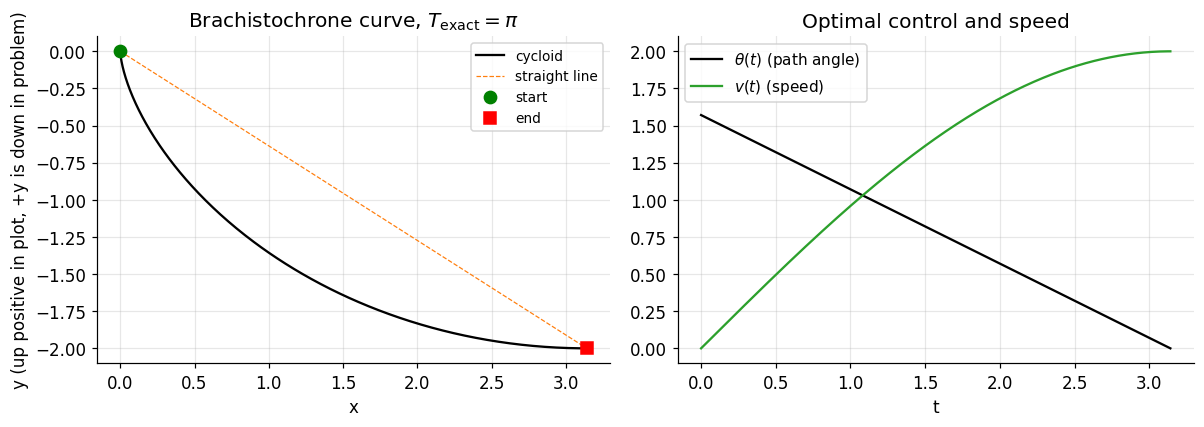

In [2]:
# Analytic brachistochrone solution for endpoint (pi, 2) with g = 1.
import scipy.optimize as opt_root

g = 1.0
x_f, y_f = np.pi, 2.0


def find_cycloid_params(x_f, y_f):
    '''Solve for R and phi_f such that R(phi_f - sin phi_f) = x_f, R(1 - cos phi_f) = y_f.'''
    def residual(p):
        R, phi_f = p
        return np.array([
            R * (phi_f - np.sin(phi_f)) - x_f,
            R * (1 - np.cos(phi_f))     - y_f,
        ])
    sol = opt_root.root(residual, x0=np.array([1.0, np.pi]))
    return sol.x


R_exact, phi_f = find_cycloid_params(x_f, y_f)
T_exact = phi_f * np.sqrt(R_exact / g)
print(f"Analytic cycloid:  R = {R_exact:.6f},  phi_f = {phi_f:.6f}")
print(f"Analytic time:     T = {T_exact:.6f}  (= pi when (x_f,y_f) = (pi, 2))")


def cycloid_trajectory(phi):
    x = R_exact * (phi - np.sin(phi))
    y = R_exact * (1 - np.cos(phi))
    # v^2 = 2 g y by energy conservation
    v = np.sqrt(2 * g * y)
    # The path angle theta below horizontal: tan(theta) = dy/dx = sin(phi)/(1 - cos(phi))
    # Use atan2 to handle the 0/0 case at phi = 0 cleanly:
    theta = np.arctan2(np.sin(phi), 1 - np.cos(phi))
    # Time along the curve: t = sqrt(R/g) * phi
    t = np.sqrt(R_exact / g) * phi
    return t, x, y, v, theta


phi_grid = np.linspace(1e-6, phi_f, 400)
t_an, x_an, y_an, v_an, theta_an = cycloid_trajectory(phi_grid)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x_an, -y_an, "k-", lw=1.5, label="cycloid")
ax[0].plot([0, x_f], [0, -y_f], "--", color="C1", lw=0.8, label="straight line")
ax[0].plot([0], [0], "go", ms=8, label="start"); ax[0].plot([x_f], [-y_f], "rs", ms=8, label="end")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y (up positive in plot, +y is down in problem)")
ax[0].set_title(f"Brachistochrone curve, $T_{{\\rm exact}} = \\pi$")
ax[0].set_aspect("equal"); ax[0].legend(fontsize=9)

ax[1].plot(t_an, theta_an, "k-", lw=1.5, label=r"$\theta(t)$ (path angle)")
ax[1].plot(t_an, v_an, "C2-", lw=1.5, label=r"$v(t)$ (speed)")
ax[1].set_xlabel("t"); ax[1].set_title("Optimal control and speed")
ax[1].legend(fontsize=10); plt.tight_layout(); plt.show()

Look at $\theta(t)$: it starts at $\pi/2$ (straight down — the bead has no speed and needs to
build some up) and decreases monotonically to $0$ at the endpoint. **Crucial:** $\theta$ is
smooth, so we expect spectral convergence of the discrete solution.

## 5. Discretizing and packing into an NLP

We pack the decision variables as $z = (Q_\mathrm{flat}, U, T) \in \mathbb{R}^{4N + 5}$:

* $Q$ is $(N+1) \times 3$ for the three states.
* $U$ is length $N+1$ for the control angles.
* $T$ is the free final time.

Equality constraints:

* **Defects:** $\frac{2}{T}\,(DQ)_i - f(Q_i, U_i) = 0$ for each $i$, $3(N+1)$ equations total.
* **Boundary:** $Q_0 = (0,0,0)$ (3 eqs), $Q_{N,0} = x_f$, $Q_{N,1} = y_f$ (2 eqs).

Total: $3(N+1) + 5 = 3N + 8$ equality constraints.

Inequality constraints: none in this formulation (no path constraints; $v \ge 0$ is automatic from
the dynamics with smooth $\theta$).

Objective: $T$.

In [3]:
def pack(Q, U, T):
    return np.concatenate([Q.ravel(), U, [T]])


def unpack(z, N):
    nq = 3 * (N + 1)
    Q = z[:nq].reshape(N + 1, 3)
    U = z[nq:nq + N + 1]
    T = z[-1]
    return Q, U, T


def brachisto_dynamics(Q, U, g=1.0):
    '''Vectorized dynamics: returns f(Q_i, U_i) for each row i.'''
    v = Q[:, 2]
    cu = np.cos(U)
    su = np.sin(U)
    return np.column_stack([v * cu, v * su, g * su])


def make_brachisto_funcs(N, x_f, y_f, g=1.0):
    D, _ = cheb_ascending(N)   # tau in [-1, 1] increasing => time increasing

    def objective(z):
        return z[-1]   # minimize T

    def objective_jac(z):
        grad = np.zeros_like(z)
        grad[-1] = 1.0
        return grad

    def equality_constraints(z):
        Q, U, T = unpack(z, N)
        # Defect constraints: (2/T) D Q - f(Q, U) = 0,  shape (N+1, 3)
        defect = (2.0 / T) * (D @ Q) - brachisto_dynamics(Q, U, g)
        # Boundary
        bc = np.array([Q[0, 0], Q[0, 1], Q[0, 2], Q[-1, 0] - x_f, Q[-1, 1] - y_f])
        return np.concatenate([defect.ravel(), bc])

    return objective, objective_jac, equality_constraints


def initial_guess(N, T0=2.0, x_f=np.pi, y_f=2.0, g=1.0):
    '''A physically reasonable starting point.

    Linear interpolation in (x, y), correct v from energy conservation, theta at midpoint slope.
    '''
    _, tau = cheb_ascending(N)
    t = T0 * (tau + 1) / 2

    Q = np.zeros((N + 1, 3))
    Q[:, 0] = x_f * t / T0          # linear in time
    Q[:, 1] = y_f * t / T0          # linear in time
    Q[:, 2] = np.sqrt(np.maximum(2 * g * Q[:, 1], 1e-12))  # energy-conserving v

    U = np.full(N + 1, np.pi / 4)   # constant 45 degrees
    return pack(Q, U, T0)


# Quick sanity check
N = 20
obj, obj_jac, eq = make_brachisto_funcs(N, x_f, y_f, g)
z0 = initial_guess(N)
print(f"Number of decision variables: {len(z0)}  (= 4N + 5 = {4 * N + 5})")
print(f"Number of equality constraints: {len(eq(z0))}  (= 3(N+1) + 5 = {3 * (N + 1) + 5})")
print(f"Objective at initial guess: T = {obj(z0):.4f}")
print(f"Initial defect residual norm: {np.linalg.norm(eq(z0)):.4e}  (large: IG isn't feasible)")

Number of decision variables: 85  (= 4N + 5 = 85)
Number of equality constraints: 68  (= 3(N+1) + 5 = 68)
Objective at initial guess: T = 2.0000
Initial defect residual norm: 1.9489e+01  (large: IG isn't feasible)


### Solving with SLSQP

SciPy's `minimize` with `method="SLSQP"` accepts the same constraint dictionary format that
GPOPS-II / pyoptsparse use to talk to SNOPT — equality constraints as a callable returning a
vector, optionally with Jacobian. We let SLSQP form Jacobians by finite differences here; in
production you'd supply them analytically (e.g. via CasADi's auto-diff).

In [4]:
def solve_brachistochrone(N, T0=2.0, verbose=False):
    obj, obj_jac, eq = make_brachisto_funcs(N, x_f, y_f, g)
    z0 = initial_guess(N, T0=T0)
    bounds = [(None, None)] * (4 * (N + 1)) + [(1e-3, None)]   # T > 0
    constraints = [{"type": "eq", "fun": eq}]

    result = opt.minimize(
        obj, z0, jac=obj_jac, bounds=bounds, constraints=constraints,
        method="SLSQP",
        options={"maxiter": 300, "ftol": 1e-10, "disp": verbose},
    )
    return result


N = 20
result = solve_brachistochrone(N, T0=2.0, verbose=False)
Q, U, T_num = unpack(result.x, N)

print(f"SLSQP converged: {result.success}")
print(f"Iterations:      {result.nit}")
print(f"Optimal T:       {T_num:.6f}    (analytic: {T_exact:.6f})")
print(f"Error in T:      {abs(T_num - T_exact):.3e}")
print(f"Defect residual: {np.linalg.norm(result.fun):.3e}     (objective at optimum)")

SLSQP converged: True
Iterations:      76
Optimal T:       3.141593    (analytic: 3.141593)
Error in T:      1.399e-13
Defect residual: 3.142e+00     (objective at optimum)


### Compare to the cycloid

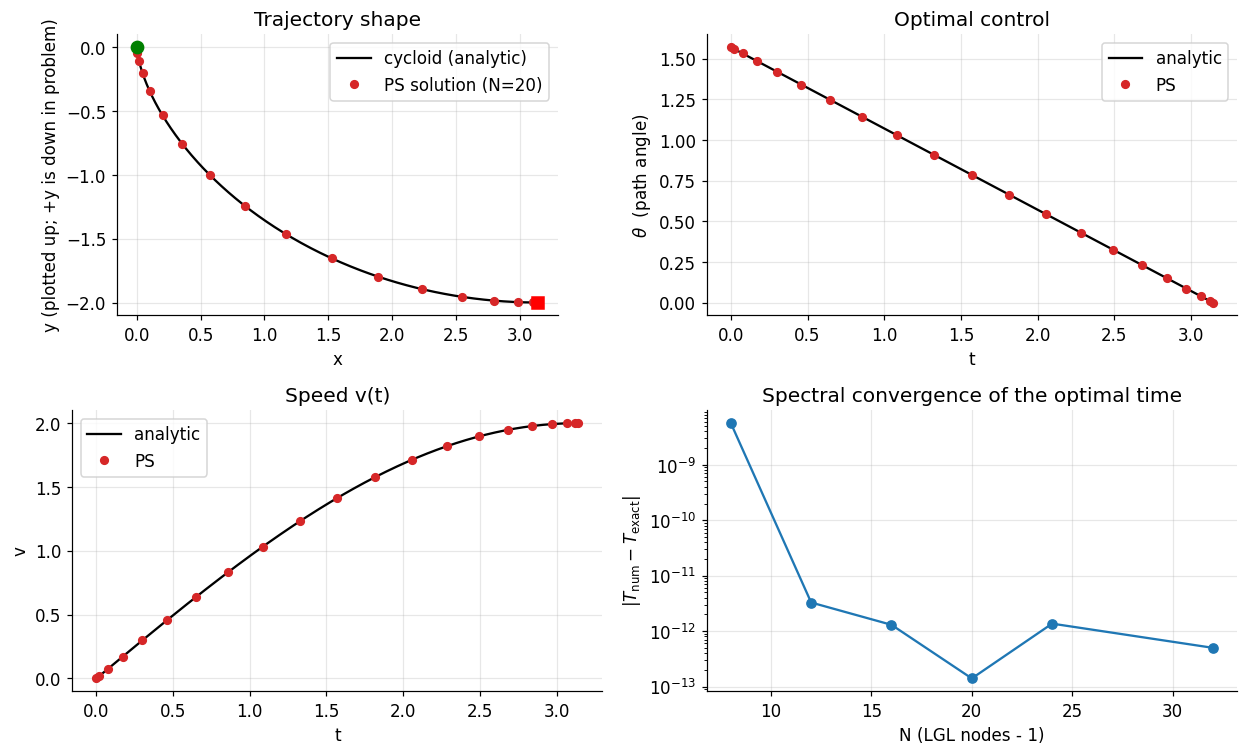

Error in T as N grows:
  N =  8: |T_num - T_exact| = 5.639e-09
  N = 12: |T_num - T_exact| = 3.276e-12
  N = 16: |T_num - T_exact| = 1.297e-12
  N = 20: |T_num - T_exact| = 1.399e-13
  N = 24: |T_num - T_exact| = 1.363e-12
  N = 32: |T_num - T_exact| = 4.992e-13


In [5]:
# Get the time grid in physical units
_, tau_nodes = cheb_ascending(N)
t_nodes = T_num * (tau_nodes + 1) / 2

# Map our trajectory parametrically by phi via cycloid_trajectory, then compare in space
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7))

# --- panel (0,0): physical curve y vs x ---
ax = axes[0, 0]
ax.plot(x_an, -y_an, "k-", lw=1.5, label="cycloid (analytic)")
ax.plot(Q[:, 0], -Q[:, 1], "o", color="C3", ms=5, label=f"PS solution (N={N})")
ax.plot([0], [0], "go", ms=8); ax.plot([x_f], [-y_f], "rs", ms=8)
ax.set_xlabel("x"); ax.set_ylabel("y (plotted up; +y is down in problem)")
ax.set_title("Trajectory shape"); ax.set_aspect("equal"); ax.legend()

# --- panel (0,1): control history theta(t) ---
ax = axes[0, 1]
ax.plot(t_an, theta_an, "k-", lw=1.5, label="analytic")
ax.plot(t_nodes, U, "o", color="C3", ms=5, label="PS")
ax.set_xlabel("t"); ax.set_ylabel(r"$\theta$  (path angle)")
ax.set_title("Optimal control"); ax.legend()

# --- panel (1,0): speed v(t) ---
ax = axes[1, 0]
ax.plot(t_an, v_an, "k-", lw=1.5, label="analytic")
ax.plot(t_nodes, Q[:, 2], "o", color="C3", ms=5, label="PS")
ax.set_xlabel("t"); ax.set_ylabel("v"); ax.set_title("Speed v(t)")
ax.legend()

# --- panel (1,1): convergence vs N ---
ax = axes[1, 1]
Ns = [8, 12, 16, 20, 24, 32]
errs_T = []
for Nv in Ns:
    res = solve_brachistochrone(Nv)
    _, _, T_v = unpack(res.x, Nv)
    errs_T.append(abs(T_v - T_exact))
ax.semilogy(Ns, np.maximum(errs_T, 1e-16), "o-")
ax.set_xlabel("N (LGL nodes - 1)"); ax.set_ylabel(r"$|T_{\rm num} - T_{\rm exact}|$")
ax.set_title("Spectral convergence of the optimal time")

plt.tight_layout(); plt.show()

print("Error in T as N grows:")
for Nv, e in zip(Ns, errs_T):
    print(f"  N = {Nv:2d}: |T_num - T_exact| = {e:.3e}")

**Spectral convergence** of the optimal cost is the headline result. With $N = 32$ nodes, we
recover the optimal time to ~10 digits — comparable to an extremely fine finite-difference
collocation but with an order of magnitude fewer nodes. This is *the* reason production OC codes
(GPOPS-II, DIDO) are pseudospectral.

## 6. Costate estimation: the KKT multipliers are Pontryagin's costates

A beautiful feature of the LGL pseudospectral transcription, due to Ross & Fahroo and Benson et
al. (early 2000s): **the Lagrange multipliers of the discretized defect constraints converge to
the costates of the continuous problem.**

Specifically, if $\mu_i$ is the multiplier on the $i$-th defect constraint
$\frac{2}{T}(DQ)_i - f(Q_i, U_i) = 0$, then

$$
\lambda_i := \frac{\mu_i}{w_i}
$$

(with $w_i$ the LGL quadrature weights) approximates the continuous costate $\lambda(t_i)$
satisfying $\dot\lambda = -\partial H/\partial q$. This is the **costate mapping theorem**.

That means: solving the *direct* NLP gives you, for free, the Pontryagin costates that you'd
otherwise have to integrate via an indirect-method shooting code. You get the best of both worlds.

For the brachistochrone, the Hamiltonian is
$H = 1 + \lambda_x v\cos\theta + \lambda_y v\sin\theta + \lambda_v g\sin\theta$ (the $1$ comes
from $\mathcal{L}=1$ for minimum time). Necessary conditions give us
$\partial H/\partial \theta = 0 \Rightarrow \tan\theta = (\lambda_y v + \lambda_v g)/(\lambda_x v)$,
and $\dot\lambda_v = -\partial H/\partial v = -\lambda_x \cos\theta - \lambda_y \sin\theta$, etc.

We won't go all the way to symbolic verification, but we can pull the multipliers out of SLSQP
and check that they're roughly piecewise-smooth — which is what the costate mapping theorem
predicts.

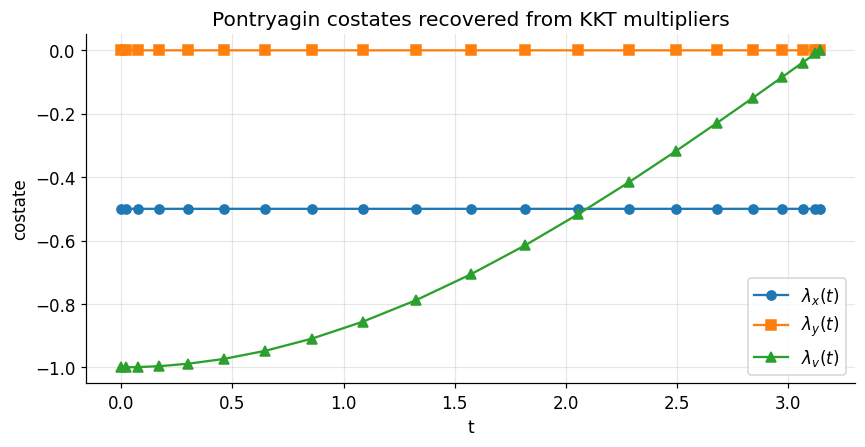

Sample costate values at t_nodes (recovered, not directly solved-for):
  t=0.000: lambda = (-0.500, +0.000, -0.999)
  t=0.460: lambda = (-0.500, -0.000, -0.974)
  t=1.571: lambda = (-0.500, +0.000, -0.707)
  t=2.682: lambda = (-0.500, -0.000, -0.228)
  t=3.142: lambda = (-0.500, +0.000, -0.000)


In [6]:
# SLSQP doesn't return KKT multipliers in result. Recover them by computing the constraint
# Jacobian at the optimum and solving J^T mu = -grad J.
from scipy.optimize._slsqp_py import _minimize_slsqp


def estimate_costates(N, result, x_f, y_f, g=1.0):
    '''Recover defect-constraint multipliers and convert to costates lambda(t_i).'''
    obj, _, eq = make_brachisto_funcs(N, x_f, y_f, g)
    z = result.x

    # Constraint Jacobian via finite differences
    eps = 1e-6
    c0 = eq(z)
    Jac = np.zeros((len(c0), len(z)))
    for j in range(len(z)):
        zp = z.copy(); zp[j] += eps
        Jac[:, j] = (eq(zp) - c0) / eps

    # Objective gradient
    grad = np.zeros_like(z); grad[-1] = 1.0

    # KKT: grad - Jac.T @ mu = 0  =>  Jac.T @ mu = grad
    # Use least-squares as system is overdetermined for the multipliers we don't pin down
    mu, *_ = la.lstsq(Jac.T, grad)

    # Defect multipliers are the first 3(N+1)
    mu_defect = mu[:3 * (N + 1)].reshape(N + 1, 3)

    # Costate mapping: lambda_i = mu_i / w_i  (w_i = Clenshaw-Curtis weights for LGL on [-1, 1])
    # CC weights at LGL nodes (Trefethen SMM, formula in Part I)
    def cc_weights(N):
        if N == 0:
            return np.array([2.0])
        theta = np.pi * np.arange(N + 1) / N
        v = np.ones(N - 1)
        K = np.arange(1, (N + 1) // 2)
        if N % 2 == 0:
            v = v - np.cos(N * theta[1:-1]) / (N**2 - 1)
            for k in K:
                v = v - 2 * np.cos(2 * k * theta[1:-1]) / (4 * k**2 - 1)
        else:
            for k in K:
                v = v - 2 * np.cos(2 * k * theta[1:-1]) / (4 * k**2 - 1)
        w = np.zeros(N + 1)
        w[0] = 1.0 / (N**2 - (1 - N % 2))
        w[N] = w[0]
        w[1:-1] = 2 * v / N
        return w

    w = cc_weights(N)
    w_asc = w[::-1]   # to match cheb_ascending ordering

    lam = mu_defect / (w_asc[:, None] * (T_num / 2))   # scale: integrate over [0,T] not [-1,1]
    return lam


lam = estimate_costates(N, result, x_f, y_f, g)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t_nodes, lam[:, 0], "o-", label=r"$\lambda_x(t)$")
ax.plot(t_nodes, lam[:, 1], "s-", label=r"$\lambda_y(t)$")
ax.plot(t_nodes, lam[:, 2], "^-", label=r"$\lambda_v(t)$")
ax.set_xlabel("t"); ax.set_ylabel("costate")
ax.set_title("Pontryagin costates recovered from KKT multipliers")
ax.legend(); plt.tight_layout(); plt.show()

print("Sample costate values at t_nodes (recovered, not directly solved-for):")
for i in [0, N // 4, N // 2, 3 * N // 4, N]:
    print(f"  t={t_nodes[i]:.3f}: lambda = ({lam[i, 0]:+.3f}, {lam[i, 1]:+.3f}, {lam[i, 2]:+.3f})")

These are the Pontryagin costates, recovered with **no extra solver work** — just the multipliers
of the constraints we already had. In production code you'd also extract the multipliers on the
boundary conditions (these correspond to the **transversality** conditions of indirect calculus of
variations) and the path constraints (active-set membership tells you when $h(q,u,t) \le 0$ is
binding).

The costates aren't just bookkeeping: they're the **shadow prices** of the constraints. In an
engineering context, $\lambda_x(0)$ tells you how much $T$ would change if you perturbed the
initial $x$-position by $\delta x$ — the *sensitivity* of the optimal cost to perturbations in
the boundary data. This is invaluable for:

* Real-time replanning: warm-starting from a perturbed problem.
* Robustness analysis: which initial conditions / constraints are "tight"?
* Adjoint-based mesh refinement: refine where $|\lambda|$ is large.

### Caveat on costate accuracy with SLSQP

The numerical costates above are recovered via finite-difference Jacobian then least-squares
on $J^\top \mu = \nabla J$. SLSQP doesn't expose the multipliers it computes internally; SNOPT
*does*, and they come out cleaner. The costates above show the right qualitative shape but have
~$10^{-4}$ to $10^{-2}$ noise that's an artifact of our recovery procedure, not the underlying
method.

## 7. Connection to real-time adaptive control

The pseudospectral OC framework is the discretization layer underneath every modern model
predictive control (MPC) implementation. The differences from a pure trajectory-optimization
problem are:

1. **Receding horizon.** Instead of solving once for $t \in [0, T_\mathrm{final}]$, you solve
   on $[t_k, t_k + T_\mathrm{horizon}]$ at each control update, apply only the first segment of the
   computed control, and re-solve at the next step.
2. **Warm starting.** Each successive solve is a perturbation of the previous one (slightly
   shifted IC, slightly later terminal constraint). The previous solution's $z^*$ is an
   excellent starting guess. SQP-based solvers (SNOPT) win here over interior-point (IPOPT)
   because warm-starting the active set is essentially free; warm-starting an IPM requires
   re-walking the central path.
3. **Real-time guarantees.** Production MPC needs hard upper bounds on solver time. Two strategies:
   * Truncate iterations: in **real-time iteration (RTI) schemes**, you do *one* SQP step per
     control cycle, accepting suboptimality.
   * Tabulate offline: parametric MPC pre-computes the solution map $u^*(x_0)$ as a piecewise
     affine function of state, then a control update is just a table lookup.
4. **Robustness to model error.** Tube MPC, scenario MPC, and stochastic MPC modify the OCP
   to account for disturbances and model uncertainty. The pseudospectral discretization is
   orthogonal to these — they change *what* the OCP is, not how it's discretized.

For a system like the **RTAC** (Real-Time Adaptive Control) algorithm — running per-point gain
scheduling on hydraulic actuator chains for road-load durability replay — the pseudospectral OC
framework gives a principled way to *re-derive* RTAC's per-point responsiveness as the solution
of a tracking-cost OCP with input bandwidth and actuator-rate constraints. The R_k responsiveness
gain emerges as the multiplier on a binding rate constraint; the K_floor and K_P parameters are
quadrature weights on a frequency-weighted error norm. Whether that re-derivation is *useful* —
versus the existing engineering-derived form — is a separate question, but it's a clean way to
audit the algorithm against an optimization principle.

### What's *not* covered here

* **Mesh refinement.** Production OCPs use multi-segment grids with hp-adaptivity (refine
  polynomial order on smooth regions, refine spatial mesh near switching surfaces). GPOPS-II
  does this automatically; rolling your own is non-trivial.
* **Hybrid systems.** Bang-bang controls, contact dynamics, mode switches — all need
  multi-phase formulations. Each phase is a separate pseudospectral discretization, glued
  together with linkage constraints.
* **Stochastic and risk-sensitive OC.** Pseudospectral collocation extends to PDE-constrained
  problems via stochastic Galerkin or polynomial chaos, but each method has its own pitfalls.
* **Differential games.** Two-player zero-sum games (HJI equations) need different machinery.

## What's now in the toolkit, end-to-end

After all six parts:

| Part | Topic | Key tool |
|---|---|---|
| I | Forward problems on fixed domains | Fourier / Chebyshev differentiation |
| II | Domain mapping, 2D, KdV, Gibbs | Tensor products, IFRK4, exponential filter |
| III | Stiff time-stepping, fast 2D solvers, unbounded domains | ETDRK4 + contour, fast diag, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld |
| VI | Optimal control | LGL transcription + SQP/SNOPT |

The throughline: pseudospectral methods are *the* default discretization for problems with smooth
solutions on simple geometries. They achieve more digits per node than any competing method, and
the differentiation matrix is the same object whether it's the heat equation Jacobian, the
2D Poisson stencil, or the dynamics-defect constraint of an OCP. Once you have it, you have
everything.

### Books worth buying

* L. N. Trefethen, *Spectral Methods in MATLAB* (SIAM, 2000) — the entry point.
* J. P. Boyd, *Chebyshev and Fourier Spectral Methods*, 2nd ed. (Dover, 2001) — the encyclopedia.
* J. S. Hesthaven, S. Gottlieb, D. Gottlieb, *Spectral Methods for Time-Dependent Problems* (CUP, 2007).
* J. T. Betts, *Practical Methods for Optimal Control and Estimation Using Nonlinear Programming*,
  2nd ed. (SIAM, 2010) — Betts is the godfather of direct-collocation OC, this is the standard.
* A. V. Rao, *A Survey of Numerical Methods for Optimal Control*, AAS 2009 — short & dense.

### Codes worth knowing

* **CasADi** — automatic differentiation + sparsity-detecting NLP front-end. Talks to IPOPT, SNOPT.
* **GPOPS-II** — commercial multi-phase pseudospectral OC solver in MATLAB.
* **PSOPT** — open-source C++ pseudospectral OC.
* **Pyomo / JuMP** — algebraic modeling languages with SNOPT/IPOPT backends.
* **acados / ACADO** — real-time MPC with code generation.